#### 농구선수의 게임 데이터를 활용한 포지션 예측을 위한 데이터 정제
- NBA 농구 선수들의 게임 기록을 데이터로 사용해서 특정 농구 선수의 포지션 예측

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../Data/basketball.csv")

In [3]:
df.head()

,Player,Pos,3P,2P,TRB,AST,STL,BLK
0,Alex Abrines,SG,1.4,0.6,1.3,0.6,0.5,0.1
1,Steven Adams,C,0.0,4.7,7.7,1.1,1.1,1.0
2,Alexis Ajinca,C,0.0,2.3,4.5,0.3,0.5,0.6
3,Chris Andersen,C,0.0,0.8,2.6,0.4,0.4,0.6
4,Will Barton,SG,1.5,3.5,4.3,3.4,0.8,0.5


### 키워드 : **EDA**

#### Column Description
- Player : 선수 이름
- Pos : 포지션(SG, C 2개만 있음)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  100 non-null    object 
 1   Pos     100 non-null    object 
 2   3P      100 non-null    float64
 3   2P      100 non-null    float64
 4   TRB     100 non-null    float64
 5   AST     100 non-null    float64
 6   STL     100 non-null    float64
 7   BLK     100 non-null    float64
dtypes: float64(6), object(2)
memory usage: 6.4+ KB


In [5]:
# Target : Pos
df.Pos.value_counts()

Pos
SG    50
C     50
Name: count, dtype: int64

#### 포지션별 설명
-> 각각의 포지션이 어떤 위치인지 알고 있어야 될 것.</br>
=> 이것은 즉, 사용하고자 하는 데이터셋의 각 Column 들에 대해 알고 있어야 한다는 뜻.</br>
➡ 어떤 데이터가 필요한지 알아야 하기 때문.

#### 데이터 시각화를 통한 EDA(탐색적 데이터 분석) 실시
: 데이터의 특징을 바탕으로 한 공간에 시각화 시킴으로써 ML 학습에 '필요한 Feature' 와 '불필요한 Feature' 를 쉽게 구분

In [6]:
# pip install koreanize_matplotlib

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

#### 스틸, 2점슛 데이터 시각화

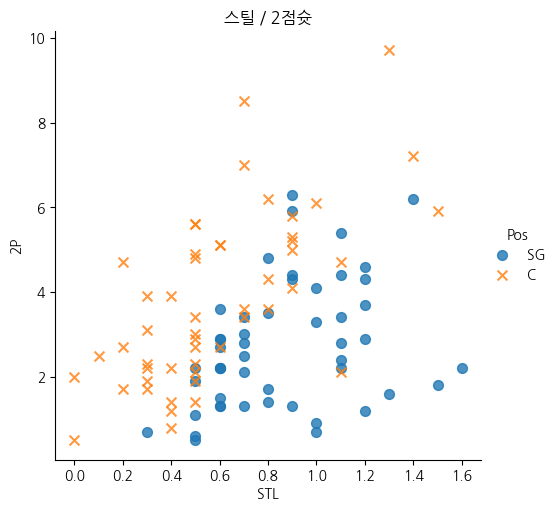

In [ ]:
sns.lmplot(
    x = 'STL',
    y = '2P',
    data = df,
    fit_reg = False, # 회귀선
    scatter_kws={'s':50}, # 좌표상 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('스틸 / 2점슛')
plt.show()

-> 스틸과 2점슛 속성의 분포도를 봤을 때, 서로 분류하기 어려운 형태이다

#### 어시스트와 2점슛 데이터 시각화

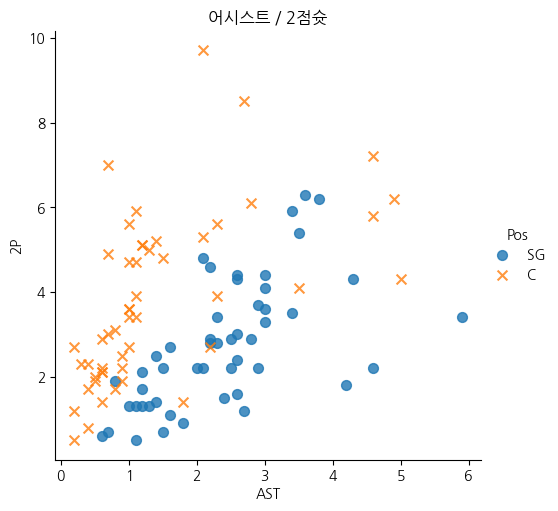

In [9]:
sns.lmplot(
    x = 'AST',
    y = '2P',
    data = df,
    fit_reg = False,
    scatter_kws={'s':50}, # 좌표상 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('어시스트 / 2점슛')
plt.show()

-> 어시와 2점슛 속성 데이터 분포를 확인했을 때, 서로 분류하기 어려운 형태이다.

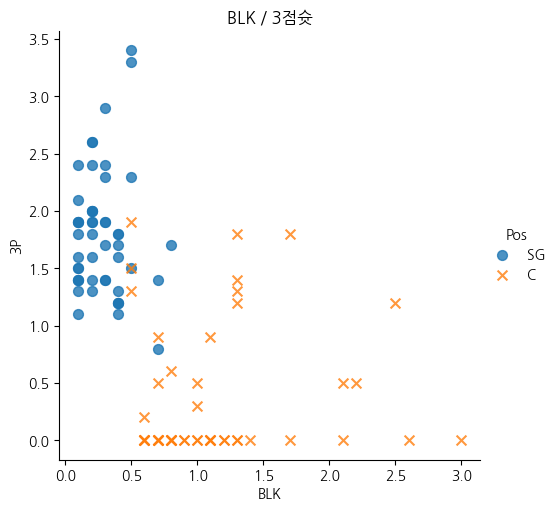

In [10]:
sns.lmplot(
    x = 'BLK',
    y = '3P',
    data = df,
    fit_reg = False,
    scatter_kws={'s':50}, # 좌표상 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('BLK / 3점슛')
plt.show()

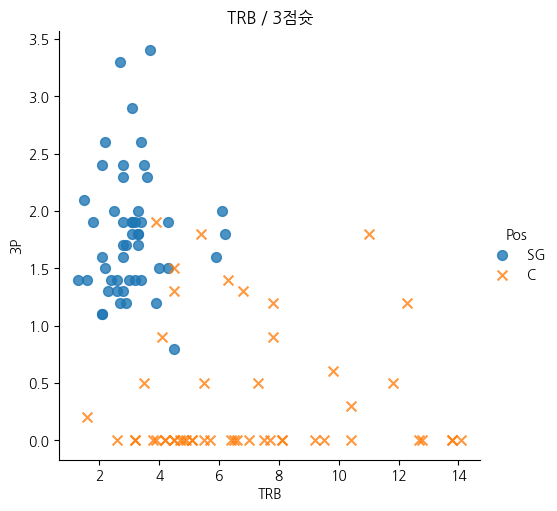

In [11]:
sns.lmplot(
    x = 'TRB',
    y = '3P',
    data = df,
    fit_reg = False,
    scatter_kws={'s':50}, # 좌표상 점의 크기
    hue='Pos',
    markers=['o', 'x']
)

plt.title('TRB / 3점슛')
plt.show()

-> EDA(Explorary Data Analysis, 탐색적 데이터 분석) 결과
> 분별력 없는 Feature를 데이터에서 제거하기 위해 시각화를 해 본 결과, <2P , AST , STL>은 분별력 없는 것으로 판단

In [12]:
# 분별력 없는 Feature를 DataSet 에서 제거
df.drop(
    ['2P', 'AST', 'STL'],
    axis='columns',
    inplace=True
)

df.head()

,Player,Pos,3P,TRB,BLK
0,Alex Abrines,SG,1.4,1.3,0.1
1,Steven Adams,C,0.0,7.7,1.0
2,Alexis Ajinca,C,0.0,4.5,0.6
3,Chris Andersen,C,0.0,2.6,0.6
4,Will Barton,SG,1.5,4.3,0.5


In [13]:
from sklearn.model_selection import train_test_split

In [15]:
# 다듬어진 Data 에서 20%를 테스트 데이터로 분류
train, test = train_test_split(
    df,
    random_state=42,
    stratify=df.Pos,
    test_size=0.2
)

In [22]:
# 데이터 갯수 확인
print(train.shape)
print(test.shape)

(80, 5)
(20, 5)


In [18]:
train.head()

,Player,Pos,3P,TRB,BLK
31,Pau Gasol,C,0.9,7.8,1.1
5,Nicolas Batum,SG,1.8,6.2,0.4
19,Allen Crabbe,SG,1.7,2.9,0.3
32,Manu Ginobili,SG,1.3,2.3,0.2
36,Danny Green,SG,1.7,3.3,0.8


In [23]:
# 데이터 저장
train.to_csv("../Data/basketball_train.csv", index=None)
test.to_csv("../Data/basketball_test.csv", index=None)
# -> index = None 옵션 주는거 확인

In [21]:
df.shape

(100, 5)